In [2]:
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st

# DATA COLLECTION 

In [3]:
df1 = pd.read_csv(r"chennai house market data 1.csv")

# DATA INSPECTION

In [4]:
df1.info

<bound method DataFrame.info of        price  area              status  bhk  bathroom  age     location  \
0      37.49   872       Ready to move    2       NaN  1.0    Sembakkam   
1      93.54  1346  Under Construction    3       2.0  NaN     Selaiyur   
2     151.00  2225  Under Construction    3       NaN  0.0    Mogappair   
3      49.00  1028       Ready to move    2       2.0  3.0     Ambattur   
4      42.28   588  Under Construction    2       1.0  0.0   Pallavaram   
...      ...   ...                 ...  ...       ...  ...          ...   
2615   27.50   750       Ready to move    2       2.0  3.0  Veppampattu   
2616   27.50   750       Ready to move    2       2.0  3.0  Veppampattu   
2617   30.00   800       Ready to move    2       2.0  3.0  Veppampattu   
2618   31.50   850       Ready to move    2       2.0  3.0  Veppampattu   
2619   34.00   900       Ready to move    2       2.0  3.0  Veppampattu   

                                   builder  
0                     

In [5]:
df1.shape

(2620, 8)

In [6]:
df1.columns        

Index(['price', 'area', 'status', 'bhk', 'bathroom', 'age', 'location',
       'builder'],
      dtype='str')

In [7]:
df1.dtypes

price       float64
area          int64
status          str
bhk           int64
bathroom    float64
age         float64
location        str
builder         str
dtype: object

In [8]:
df1.head(5)

,price,area,status,bhk,bathroom,age,location,builder
0,37.49,872,Ready to move,2,NaN,1.0,Sembakkam,MP Developers
1,93.54,1346,Under Construction,3,2.0,NaN,Selaiyur,DAC Promoters
2,151.00,2225,Under Construction,3,NaN,0.0,Mogappair,Casagrand Builder Private Limited
3,49.00,1028,Ready to move,2,2.0,3.0,Ambattur,Dugar Housing Builders
4,42.28,588,Under Construction,2,1.0,0.0,Pallavaram,Radiance Realty Developers India Ltd


In [9]:
df1.tail(5)

,price,area,status,bhk,bathroom,age,location,builder
2615,27.5,750,Ready to move,2,2.0,3.0,Veppampattu,Velan Housing Properties
2616,27.5,750,Ready to move,2,2.0,3.0,Veppampattu,Velan Housing Properties
2617,30.0,800,Ready to move,2,2.0,3.0,Veppampattu,Velan Housing Properties
2618,31.5,850,Ready to move,2,2.0,3.0,Veppampattu,Velan Housing Properties
2619,34.0,900,Ready to move,2,2.0,3.0,Veppampattu,Velan Housing Properties


In [10]:
df1.sample(5)

,price,area,status,bhk,bathroom,age,location,builder
12,407.0,2200,Under Construction,3,NaN,0.0,Gopalapuram,Pushkar Properties Pvt Ltd
1062,191.0,2474,Ready to move,4,NaN,6.0,Iyappanthangal,Prestige Estates Projects Ltd
862,342.0,1951,Under Construction,3,NaN,0.0,Kotturpuram,Appaswamy Real Estate
1905,34.0,675,Ready to move,2,2.0,3.0,Elandanur,seller
1022,104.0,1745,Ready to move,3,NaN,4.0,Kolapakkam,Poojaa Foundation


In [11]:
df1.isnull().sum()

price          0
area           0
status         0
bhk            0
bathroom    1217
age          891
location       0
builder        0
dtype: int64

In [12]:
df1.describe()

,price,area,bhk,bathroom,age
count,2620.000000,2620.000000,2620.000000,1403.000000,1729.000000
mean,93.834683,1282.925191,2.443893,2.359230,1.355119
std,113.609349,692.566319,0.811984,0.844951,2.102682
min,12.830000,300.000000,1.000000,1.000000,0.000000
25%,42.000000,877.000000,2.000000,2.000000,0.000000
50%,61.735000,1091.500000,2.000000,2.000000,0.000000
75%,90.000000,1471.250000,3.000000,3.000000,3.000000
max,1422.000000,6700.000000,8.000000,7.000000,32.000000


In [47]:
print(df1['builder'].unique())

<ArrowStringArray>
[                       'MP Developers',
                        'DAC Promoters',
    'Casagrand Builder Private Limited',
               'Dugar Housing Builders',
 'Radiance Realty Developers India Ltd',
             'Traventure Homes Pvt Ltd',
                            'Urbanrise',
       'Navin Housing Properties P LTD',
     'Jones foundation private limited',
                           'Isha Homes',
 ...
                  'Dee Star Properties',
              'Chennai Gated Community',
                               'Balaji',
                            'MrPincode',
                           'GJ ESTATES',
                            'Venkatesh',
                        'DJ Properties',
                           'Dhivagaran',
                  'MAXWORTH PROPERTIES',
             'Velan Housing Properties']
Length: 122, dtype: str


In [49]:
print(df1['location'].unique())

<ArrowStringArray>
[                   'Sembakkam',                     'Selaiyur',
                    'Mogappair',                     'Ambattur',
                   'Pallavaram',                'Virugambakkam',
                'Thirumazhisai',                   'Moolakadai',
                'Ottiyambakkam',                'Perungalathur',
 ...
              'Rathinamangalam',                 'Nandambakkam',
                 'Kuthambakkam',                  'Thirumalpur',
          'Mahindra World City', 'Oragadam Industrial Corridor',
            'Ragavendra Colony',   'Ambattur INDUSTRIAL ESTATE',
                  'Mannivakkam',             'Kil Ayanambakkam']
Length: 155, dtype: str


# DATA CLEANING 

In [20]:
"""Replacing the missing values of bathroom with mean of number bathrooms in other houses of their locality"""

bathroom_means = df1.groupby("location")["bathroom"].mean()
df1.loc[df1["bathroom"].isna(), "bathroom"] = (
    df1.loc[df1["bathroom"].isna(), "location"].map(bathroom_means)
)

""" global fallback for locations with no Non-missing Value """
df1 = df1.fillna({"bathroom": df1["bathroom"].median()})


In [21]:
df1['bathroom'].isna().sum()


np.int64(0)

In [22]:
"""Replacing the missing values of age with mean of house age in their locality"""

age_means = df1.groupby("location")["age"].mean()
df1.loc[df1["age"].isna(), "age"] = (
    df1.loc[df1["age"].isna(), "location"].map(age_means)
)

""" global fallback for locations with no Non-missing Value """
df1 = df1.fillna({"age": df1["age"].median()})

In [23]:
df1['age'].isna().sum()

np.int64(0)

In [24]:
df1[["bathroom", 'age']]

,bathroom,age
0,2.022222,1.000000
1,2.000000,0.296296
2,2.142857,0.000000
3,2.000000,3.000000
4,1.000000,0.000000
...,...,...
2615,2.000000,3.000000
2616,2.000000,3.000000
2617,2.000000,3.000000
2618,2.000000,3.000000


In [25]:
df1[['bathroom', 'age']].dtypes

bathroom    float64
age         float64
dtype: object

In [26]:
df1['bathroom'] = df1['bathroom'].astype('int64')

In [27]:
df1['age'] = df1['age'].astype('int64')

In [28]:
df1[['bathroom', 'age']].dtypes

bathroom    int64
age         int64
dtype: object

In [29]:
df1[["bathroom", 'age']]

,bathroom,age
0,2,1
1,2,0
2,2,0
3,2,3
4,1,0
...,...,...
2615,2,3
2616,2,3
2617,2,3
2618,2,3


In [30]:
df1.describe()

,price,area,bhk,bathroom,age
count,2620.000000,2620.000000,2620.000000,2620.000000,2620.000000
mean,93.834683,1282.925191,2.443893,2.182824,1.171374
std,113.609349,692.566319,0.811984,0.709244,1.996757
min,12.830000,300.000000,1.000000,1.000000,0.000000
25%,42.000000,877.000000,2.000000,2.000000,0.000000
50%,61.735000,1091.500000,2.000000,2.000000,0.000000
75%,90.000000,1471.250000,3.000000,2.000000,2.000000
max,1422.000000,6700.000000,8.000000,7.000000,32.000000


# Feature Engineering & Outliers Detection

In [31]:


df1["price_per_sqft"] = df1["price"] / df1["area"]

# Remove extreme outliers using IQR
Q1 = df1["price_per_sqft"].quantile(0.25)
Q3 = df1["price_per_sqft"].quantile(0.75)
IQR = Q3 - Q1
df1 = df1[(df1["price_per_sqft"] >= Q1 - 1.5*IQR) & (df1["price_per_sqft"] <= Q3 + 1.5*IQR)]
df1 = df1.drop(columns=["price_per_sqft"])

# EDA

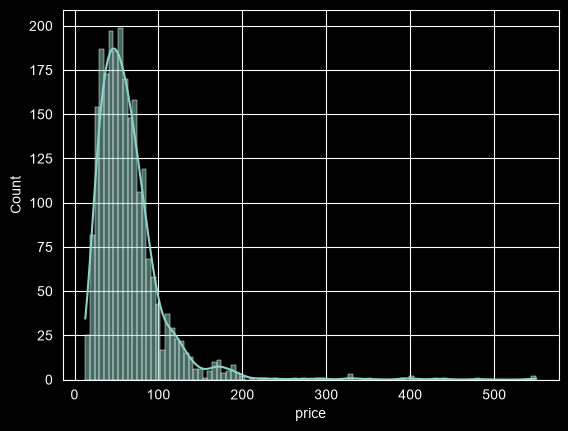

In [32]:
# Distribution of target
sns.histplot(df1["price"], kde=True)
plt.show()

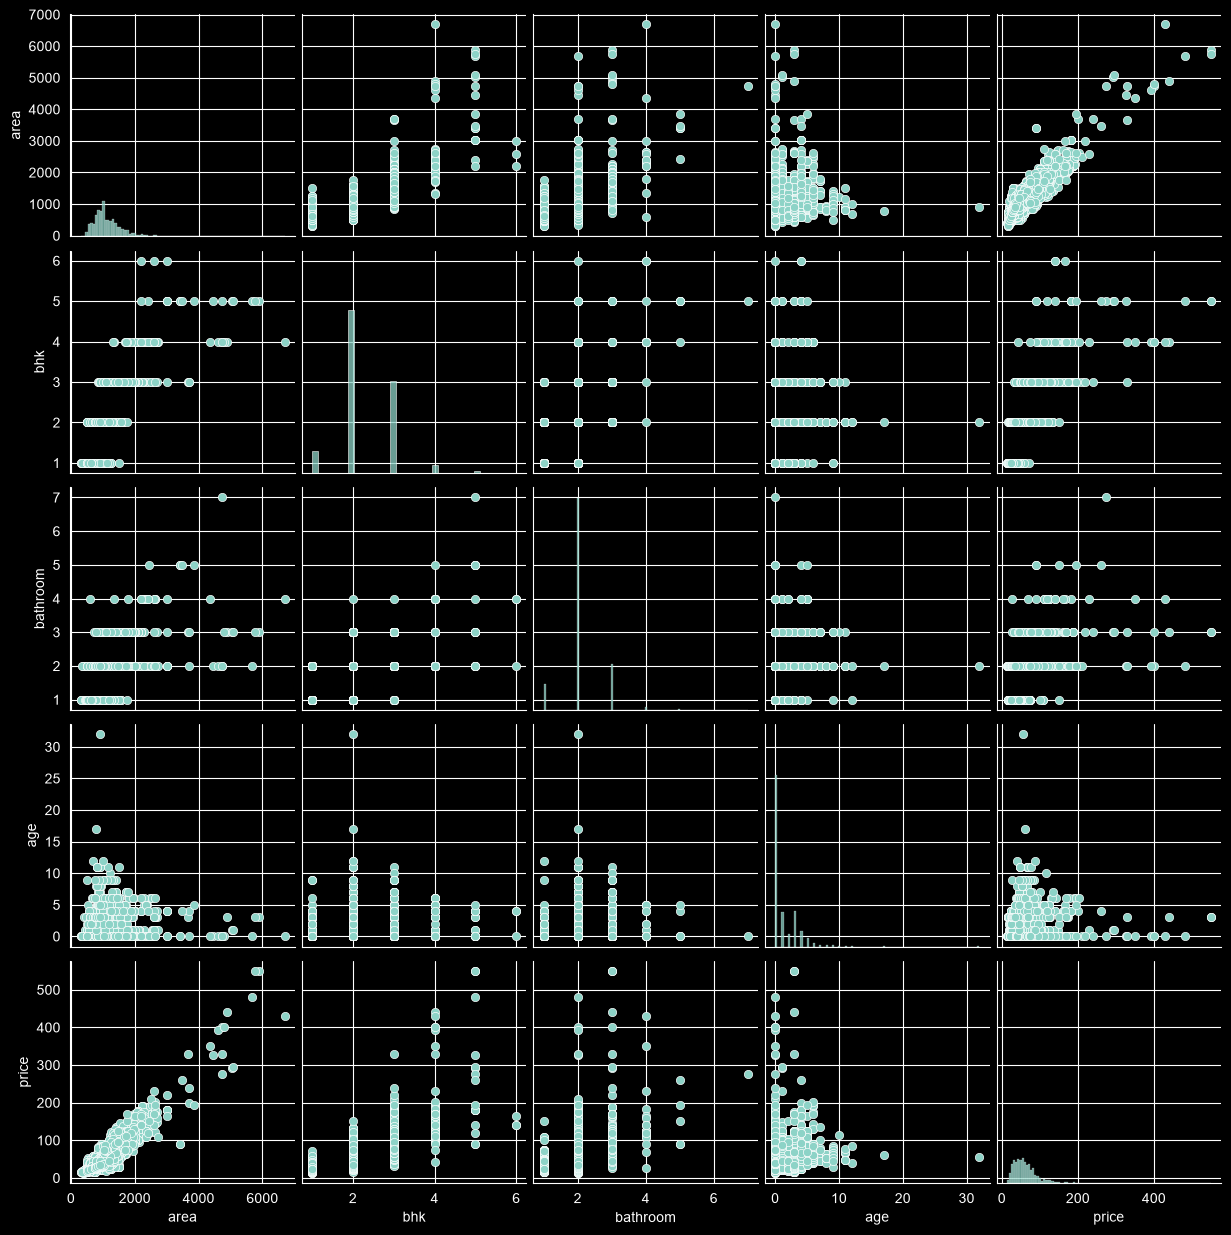

In [33]:
# Numerical feature relationships
sns.pairplot(df1[["area", "bhk", "bathroom", "age", "price"]])
plt.show()

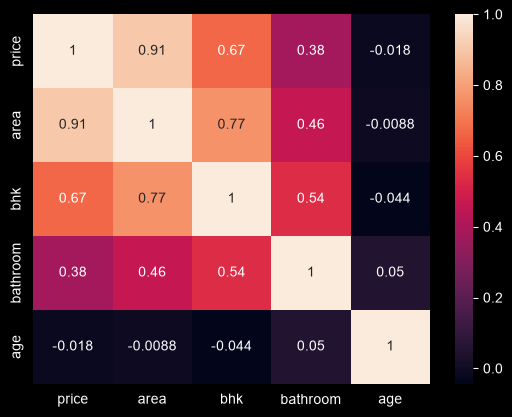

In [34]:
# Correlation
sns.heatmap(df1.select_dtypes("number").corr(), annot=True)
plt.show()

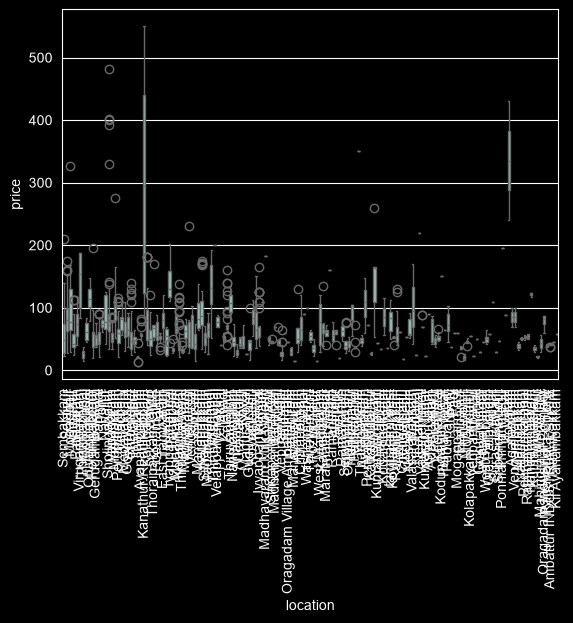

In [35]:
# Categorical feature analysis
sns.boxplot(x="location", y="price", data=df1)
plt.xticks(rotation=90)
plt.show()

# PREPROCESSING

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = ["area", "bhk", "bathroom", "age"]
categorical_features = ["status", "location", "builder"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Log-transform target
y = np.log1p(df1["price"])
X = df1.drop("price", axis=1)

# MODEL BUILDING

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Split data
X = df1.drop("price", axis=1)
y = df1["price"]

# MODEL TRAINING

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['area','status','bhk',...,'age','location','builder']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated

# MODEL EVALUTION

In [39]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)
print("R²:", r2_score(y_test, y_pred))

RMSE: 11.862184440614795
R²: 0.9328535007759611


# MODEL PREDICTION

In [40]:
new_house = pd.DataFrame({
    "area": [1200],
    "bhk": [2],
    "bathroom": [2],
    "age": [5],
    "status": ["ready"],
    "location": ["Chennai"],
    "builder": ["ABC"]
})

prediction = model.predict(new_house)

price_lakh = prediction[0]
if price_lakh < 1:
    print(f"Predicted Price: ₹{price_lakh * 100000:,.0f}")
elif price_lakh < 100:
    print(f"Predicted Price: ₹{price_lakh:,.2f} lakh")
elif price_lakh < 100000:
    print(f"Predicted Price: ₹{price_lakh / 100:,.2f} crore")
else:
    print(f"Predicted Price: ₹{price_lakh / 100000:,.2f} thousand crore")


Predicted Price: ₹69.86 lakh


# VISUALIZATION

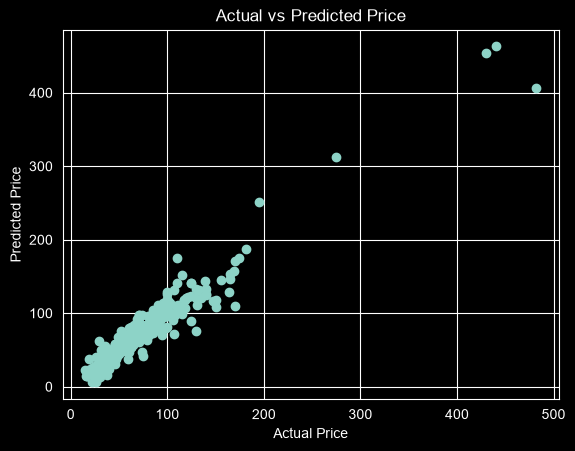

In [41]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

# MODEL SAVING

In [42]:
import joblib

joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']